# WZA SNP-number SD correction — audit & isotonic fix (current 3-class data)

**Data:** `results/clq90/wza_in/{model}_{class}_gen9_bio1.csv` — gen9, blocks_mcf90,
post-Kf_w AF, 3 classes (snp / sv / smallindel), 3 models (kendall / lfmm / binomial).

**Production statistic reproduced exactly** (from `wza_script.py`): genome-wide
rank-transform `pVal = rank(pval)/N`, `z = Φ⁻¹(1−pVal)`, weighted-Z per block
`Z = Σ(pq·z)/√Σpq²` (pq = MAF·(1−MAF)), big blocks capped by resample-averaging
(cap: snp 1000, sv/smallindel 350). *Not* wza_core's raw-p Z (which is ~2× off).

**Correction:** each block's Z → p by standardizing against the null **mean & SD of
Z as a function of block SNP-count**, estimated by a rolling window and then
smoothed. The paper uses a polynomial purely to *interpolate* that empirical curve;
we compare deg-2 (canonical), deg-7 (author email), and a **monotone-non-decreasing
isotonic** SD fit (SD physically should not fall as n grows).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.isotonic import IsotonicRegression

GEA = "/global/scratch/users/tbellg/kmate/analysis/grenenet_selection"
WIN = f"{GEA}/phase1_replication/results/clq90/wza_in"
WOUT= f"{GEA}/phase1_replication/results/clq90/wza"   # committed production deg2 outputs
MODELS=["kendall","lfmm","binomial"]; CLASSES=["snp","sv","smallindel"]
CAP={"snp":1000,"sv":350,"smallindel":350}
ROLLER,MINE = 50,40          # production deg2 rolling params
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":.3})

def prod_blockZ(model, cls, maf=0.05, resamples=100, seed=0):
    "Production-faithful per-block weighted-Z (rank-transform + cap-resample)."
    df = pd.read_csv(f"{WIN}/{model}_{cls}_gen9_bio1.csv")
    d = df[df["MAF"] > maf].copy()
    d = d[d["block"].astype(str).ne("") & d["block"].notna()]
    N = len(d)
    pv = (d["pval"].rank()/N).clip(lower=1e-15).replace(1, 1-1e-3)
    d["z"]  = norm.ppf(1 - pv.to_numpy())
    d["pq"] = d["MAF"]*(1-d["MAF"])
    num = (d["pq"]*d["z"]).groupby(d["block"]).sum()
    den = np.sqrt((d["pq"]**2).groupby(d["block"]).sum())
    cnt = d.groupby("block").size()
    res = pd.DataFrame({"SNPs_raw":cnt, "Z":num/den, "MAF":d.groupby("block")["MAF"].mean()})
    res = res[res["SNPs_raw"]>=2].copy()
    cap = CAP[cls]; res["SNPs"]=res["SNPs_raw"].clip(upper=cap)
    big = res.index[res["SNPs_raw"]>cap]
    if len(big):
        rng=np.random.default_rng(seed)
        gd={b:g for b,g in d[d["block"].isin(big)].groupby("block")}
        for b in big:
            s=gd[b]; pq=s["pq"].to_numpy(); z=s["z"].to_numpy(); n=len(s)
            res.loc[b,"Z"]=np.mean([ (pq[i]*z[i]).sum()/np.sqrt((pq[i]**2).sum())
                                     for i in (rng.choice(n,cap,replace=False) for _ in range(resamples))])
    return res.reset_index().rename(columns={"index":"block"})

def roll_curve(res, roller=ROLLER, minE=MINE):
    "Empirical rolling mean/SD of Z vs SNP count (the interpolation target)."
    s=res[res["Z"].notna()].sort_values("SNPs")
    var=s["Z"].rolling(roller,min_periods=minE).var()
    mean=s["Z"].rolling(roller,min_periods=minE).mean()
    x=s["SNPs"].rolling(roller,min_periods=minE).mean()
    m=var.notna()
    return x[m].to_numpy(), mean[m].to_numpy(), np.sqrt(var[m].to_numpy())

def predict(res, x, mean_e, sd_e, how):
    "Return (mean_pred, sd_pred) per block. deg2/deg7 = production (polynomial mean"
    " AND SD, matching wza_script.adjust_WZA_with_spline); isotonic = empirical-interp"
    " mean + monotone-non-decreasing SD."
    n=res["SNPs"].to_numpy()
    if how in ("deg2","deg7"):
        d=2 if how=="deg2" else 7
        mp=np.poly1d(np.polyfit(x,mean_e,d))(n); sd=np.poly1d(np.polyfit(x,sd_e,d))(n)
    else:
        mp=np.interp(n, x, mean_e)                 # empirical mean, flat beyond support
        ir=IsotonicRegression(increasing=True, out_of_bounds="clip"); ir.fit(x,sd_e)
        sd=ir.predict(n)
    return mp, sd

def zpval(res, mp, sd):
    with np.errstate(invalid="ignore"):
        return 1-norm.cdf(res["Z"].to_numpy(), loc=mp, scale=sd)

# precompute per-block Z once per (model,class) — reused across sections
BLK={(m,c):prod_blockZ(m,c) for m in MODELS for c in CLASSES}
print("computed block-Z for", len(BLK), "model x class combos (production statistic)")

computed block-Z for 9 model x class combos (production statistic)


## 1. Block-size distribution — the large-n tail is nearly empty

Our clq0.9/mcf90 blocks are small; the number of windows falls off fast with SNP
count. Past the 95–99th percentile there are too few windows to estimate the null
SD, so any correction must **interpolate**, never **extrapolate**, there.

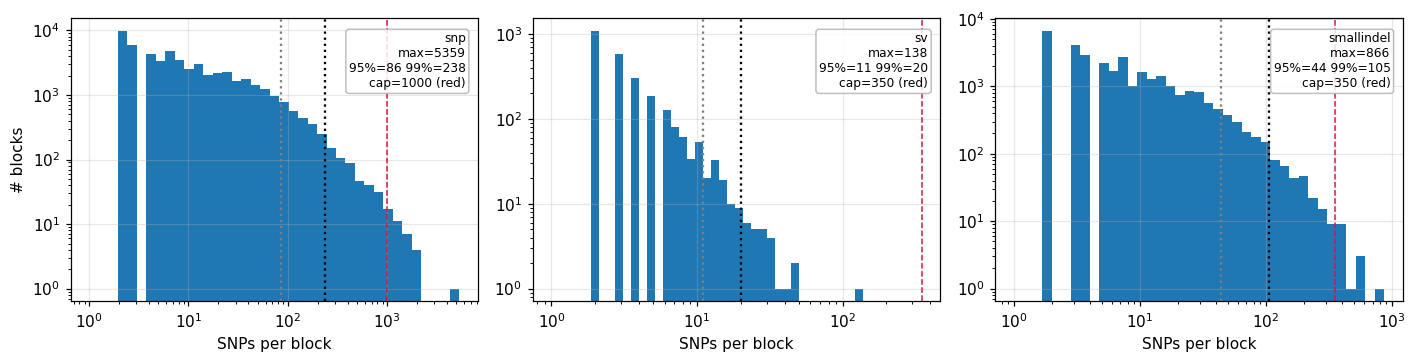

blocks > cap (get resample-capped): {'snp': 33, 'sv': 0, 'smallindel': 15}


In [2]:
fig,ax=plt.subplots(1,3,figsize=(13,3.4))
for j,c in enumerate(CLASSES):
    n=BLK[("kendall",c)]["SNPs_raw"].to_numpy()   # SNP count is model-independent
    ax[j].hist(n, bins=np.logspace(0,np.log10(n.max()+1),40))
    ax[j].set_xscale("log"); ax[j].set_yscale("log")
    ax[j].axvline(CAP[c],color="crimson",ls="--",lw=1)
    p95,p99=np.percentile(n,95),np.percentile(n,99)
    ax[j].axvline(p95,color="gray",ls=":"); ax[j].axvline(p99,color="k",ls=":")
    ax[j].set_xlabel("SNPs per block"); ax[j].set_ylabel("# blocks" if j==0 else "")
    ax[j].annotate(f"{c}\nmax={int(n.max())}\n95%={p95:.0f} 99%={p99:.0f}\ncap={CAP[c]} (red)",
        xy=(0.97,0.95),xycoords="axes fraction",ha="right",va="top",fontsize=8,
        bbox=dict(boxstyle="round,pad=0.25",fc="white",ec="0.7",alpha=.85))
fig.tight_layout(); plt.show()
print("blocks > cap (get resample-capped):",
      {c:int((BLK[('kendall',c)]['SNPs_raw']>CAP[c]).sum()) for c in CLASSES})

## 2. Empirical null SD vs SNP-count — deg-2 descends, deg-7 explodes, isotonic holds

Points = empirical rolling SD of Z (the target). Lines = deg-2, deg-7, and monotone
isotonic fits. Red dashed = the production cap. **deg-2 turns over and *descends*
past its peak (under-predicting SD → fabricated significance); deg-7 overfits and
explodes in the sparse tail; isotonic is monotone and flattens gracefully.**
y-axis clipped to the empirical range (deg-7 often shoots far above).

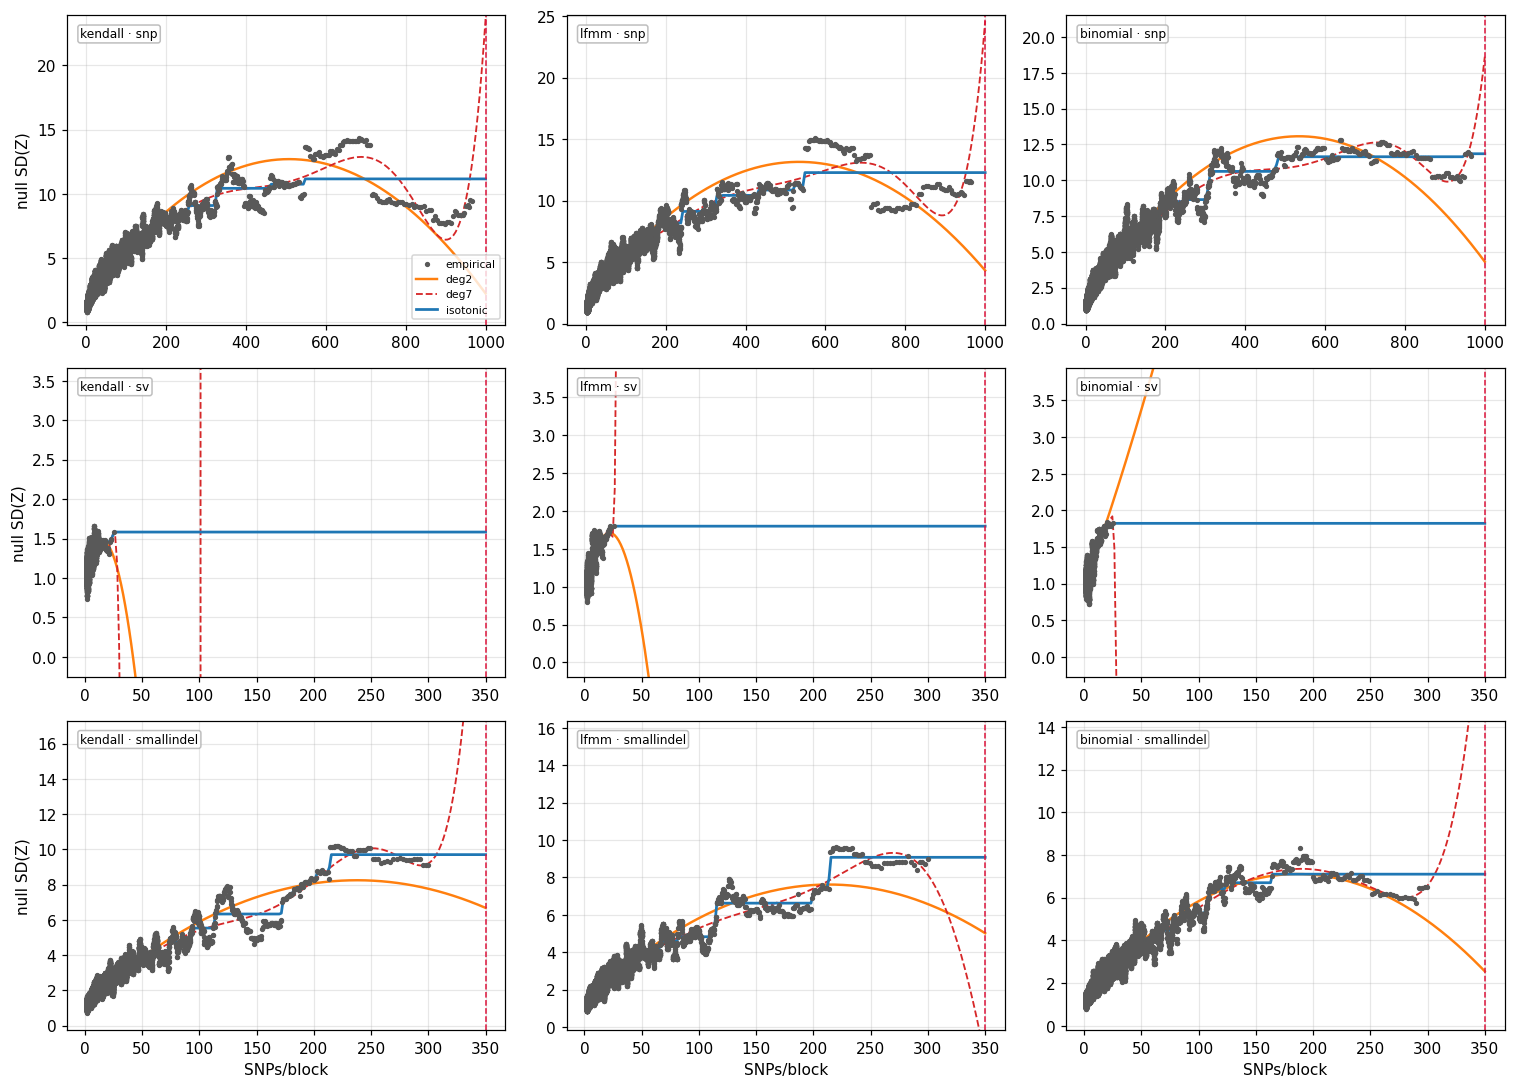

In [3]:
fig,axz=plt.subplots(3,3,figsize=(14,10),sharex=False)
for i,c in enumerate(CLASSES):
    for j,m in enumerate(MODELS):
        a=axz[i,j]; res=BLK[(m,c)]
        x,me,sde=roll_curve(res)
        a.scatter(x,sde,s=6,color="0.35",label="empirical",zorder=3)
        gx=np.linspace(x.min(),max(x.max(),CAP[c]),200)
        a.plot(gx,np.poly1d(np.polyfit(x,sde,2))(gx),color="tab:orange",lw=1.6,label="deg2")
        a.plot(gx,np.poly1d(np.polyfit(x,sde,7))(gx),color="tab:red",lw=1.2,ls="--",label="deg7")
        ir=IsotonicRegression(increasing=True,out_of_bounds="clip"); ir.fit(x,sde)
        a.plot(gx,ir.predict(gx),color="tab:blue",lw=1.8,label="isotonic")
        a.axvline(CAP[c],color="crimson",ls="--",lw=1)
        lo,hi=np.nanmin(sde),np.nanmax(sde)
        a.set_ylim(min(0,lo-1), hi*1.6+1)
        a.set_xlabel("SNPs/block" if i==2 else ""); a.set_ylabel("null SD(Z)" if j==0 else "")
        a.annotate(f"{m} · {c}",xy=(0.03,0.96),xycoords="axes fraction",va="top",fontsize=8,
            bbox=dict(boxstyle="round,pad=0.2",fc="white",ec="0.7",alpha=.85))
        if i==0 and j==0: a.legend(fontsize=7,loc="lower right")
fig.tight_layout(); plt.show()

## 3. Fabrication under deg-2 (current production) — the regression

For each model×class we recompute Z_pVal under **deg-2** (production: polynomial mean
AND SD) and count fabricated `p==0` and `NaN`. deg-2 sends blocks to p==0 not because
their signal is extreme but because its predicted SD **collapses at the cap**, so a
block's *honest* standardised deviation is tiny.

The scatter plots each deg-2 p==0 block's **honest standardised deviation**
`(Z − mean) / SD_empirical` (using the well-estimated empirical/isotonic SD, not
deg-2's collapsed one). A genuine p≈0 needs ≳5σ (dashed line); these blocks sit at
only ~1–3σ — i.e. deg-2's p==0 is an artifact of SD under-prediction, not real
significance. (Raw weighted-Z ≈ 20–43 for these blocks, but that is *not* a
standardised z — the honest null SD here is ~9–12, so the true deviation is ~2σ.)

   model      class  blocks  p==0  NaN
 kendall        snp   53596     3    0
    lfmm        snp   53596     0    0
binomial        snp   53596     1    0
 kendall         sv    2626     0    4
    lfmm         sv    2626     0    1
binomial         sv    2626     0    0
 kendall smallindel   31451     0    0
    lfmm smallindel   31451     0    0
binomial smallindel   31451     0    0

deg-2 outputs with >=1 fabricated p==0: 2/9 ; with NaN: 2/9


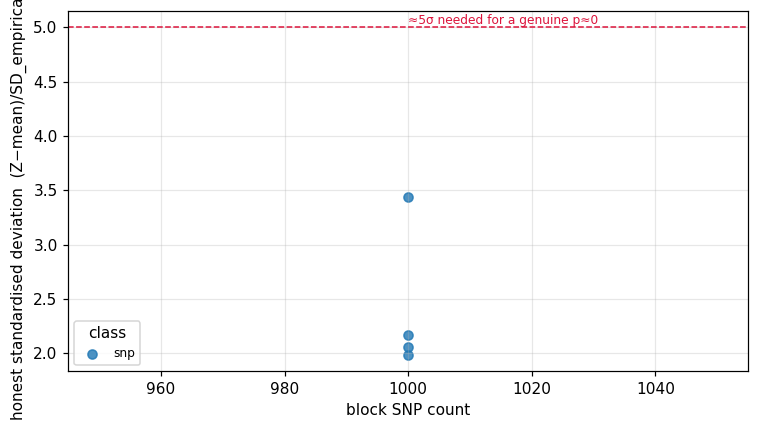


deg-2 p==0 blocks and their HONEST deviation (σ) — should be well below 5:
   model class     block  SNPs         Z  honest_sigma
 kendall   snp Chr3_6144  1000 20.433463      1.986254
 kendall   snp Chr2_2819  1000 21.205599      2.055411
 kendall   snp Chr4_5404  1000 22.511302      2.172356
binomial   snp Chr3_6144  1000 43.259489      3.439418


In [4]:
rows=[]; fab=[]
for c in CLASSES:
    for m in MODELS:
        res=BLK[(m,c)]; x,me,sde=roll_curve(res)
        mp2,sd2=predict(res,x,me,sde,"deg2"); p=zpval(res,mp2,sd2)
        mpi,sdi=predict(res,x,me,sde,"isotonic")               # honest SD for standardisation
        std_dev=(res["Z"].to_numpy()-mpi)/sdi                   # honest # of sigma
        nz=int((p==0).sum()); nn=int(np.isnan(p).sum())
        rows.append((m,c,len(res),nz,nn))
        z0=res.assign(p=p,sdev=std_dev)[lambda d:d["p"]==0]
        for _,r in z0.iterrows(): fab.append((m,c,r["block"],r["SNPs"],r["Z"],r["sdev"]))
tab=pd.DataFrame(rows,columns=["model","class","blocks","p==0","NaN"])
print(tab.to_string(index=False))
print("\ndeg-2 outputs with >=1 fabricated p==0: %d/9 ; with NaN: %d/9"
      % ((tab['p==0']>0).sum(),(tab['NaN']>0).sum()))
fab=pd.DataFrame(fab,columns=["model","class","block","SNPs","Z","honest_sigma"])
fig,ax=plt.subplots(figsize=(7,4))
for c,mk in zip(CLASSES,"osd"):
    s=fab[fab["class"]==c]
    if len(s): ax.scatter(s["SNPs"],s["honest_sigma"],marker=mk,label=c,alpha=.8)
ax.axhline(5,color="crimson",ls="--",lw=1)
ax.annotate("≈5σ needed for a genuine p≈0",xy=(0.5,5),xycoords=("axes fraction","data"),
            va="bottom",fontsize=8,color="crimson")
ax.set_xlabel("block SNP count")
ax.set_ylabel("honest standardised deviation  (Z−mean)/SD_empirical  [σ]")
ax.legend(fontsize=8,title="class"); fig.tight_layout(); plt.show()
print("\ndeg-2 p==0 blocks and their HONEST deviation (σ) — should be well below 5:")
print(fab.reindex(fab['honest_sigma'].abs().sort_values().index)[
      ['model','class','block','SNPs','Z','honest_sigma']].head(8).to_string(index=False))

## 4. The fix — empirical mean + monotone-isotonic SD

Standardize against the empirical rolling **mean** (piecewise-linear interp, flat
beyond support) and a **monotone-non-decreasing isotonic SD** (flat beyond support).
No polynomial extrapolation. Recompute p; count fabricated p==0 / NaN. SV is shown
explicitly (its cap never binds — max block ≪ cap — so it relies entirely on the
isotonic flattening rather than a plateau).

   model      class  deg2_p0  deg2_NaN  deg7_p0  deg7_NaN  iso_p0  iso_NaN
 kendall        snp        3         0        0         0       0        0
    lfmm        snp        0         0        0         0       0        0
binomial        snp        1         0        0         0       0        0
 kendall         sv        0         4        0         8       0        0
    lfmm         sv        0         1        0         0       0        0
binomial         sv        0         0        1        11       0        0
 kendall smallindel        0         0        0         0       0        0
    lfmm smallindel        0         0        2        16       0        0
binomial smallindel        0         0        0         0       0        0

TOTAL fabricated p==0 :  deg2=4  deg7=3  isotonic=0
TOTAL NaN             :  deg2=5  deg7=35  isotonic=0


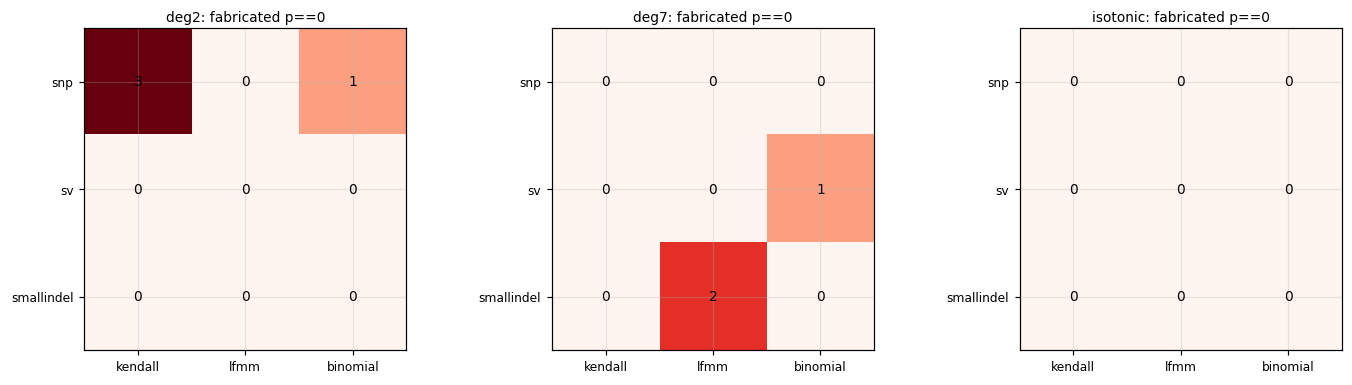

In [5]:
rows=[]
for c in CLASSES:
    for m in MODELS:
        res=BLK[(m,c)]; x,me,sde=roll_curve(res)
        out={}
        for how in ("deg2","deg7","isotonic"):
            mp,sd=predict(res,x,me,sde,how); p=zpval(res,mp,sd)
            out[how]=(int((p==0).sum()), int(np.isnan(p).sum()))
        rows.append((m,c,out["deg2"][0],out["deg2"][1],out["deg7"][0],out["deg7"][1],
                     out["isotonic"][0],out["isotonic"][1]))
fix=pd.DataFrame(rows,columns=["model","class","deg2_p0","deg2_NaN","deg7_p0","deg7_NaN","iso_p0","iso_NaN"])
print(fix.to_string(index=False))
print("\nTOTAL fabricated p==0 :  deg2=%d  deg7=%d  isotonic=%d"%(fix.deg2_p0.sum(),fix.deg7_p0.sum(),fix.iso_p0.sum()))
print("TOTAL NaN             :  deg2=%d  deg7=%d  isotonic=%d"%(fix.deg2_NaN.sum(),fix.deg7_NaN.sum(),fix.iso_NaN.sum()))
# heatmap of p==0 counts per scheme
fig,ax=plt.subplots(1,3,figsize=(13,3.6))
for k,(how,col) in enumerate([("deg2","deg2_p0"),("deg7","deg7_p0"),("isotonic","iso_p0")]):
    M=fix.pivot(index="class",columns="model",values=col).reindex(index=CLASSES,columns=MODELS)
    im=ax[k].imshow(M.values,cmap="Reds",vmin=0,vmax=max(1,fix[["deg2_p0","deg7_p0","iso_p0"]].values.max()))
    ax[k].set_xticks(range(3),MODELS,fontsize=8); ax[k].set_yticks(range(3),CLASSES,fontsize=8)
    for yi in range(3):
        for xj in range(3): ax[k].text(xj,yi,int(M.values[yi,xj]),ha="center",va="center",fontsize=9)
    ax[k].annotate(f"{how}: fabricated p==0",xy=(0.5,1.02),xycoords="axes fraction",ha="center",fontsize=9)
fig.tight_layout(); plt.show()

## 5. Validation — QQ / λ and hit-movement

**QQ** of Z_pVal (deg2 vs isotonic) per model×class with genomic-inflation λ; a
fabricating scheme shows a spike of points pinned at the top (−log10 p → ∞).
**Hit-movement:** BH-sig block counts and the fate of specific deg-2 "hits"
(e.g. Chr3_6144) under the isotonic fix.

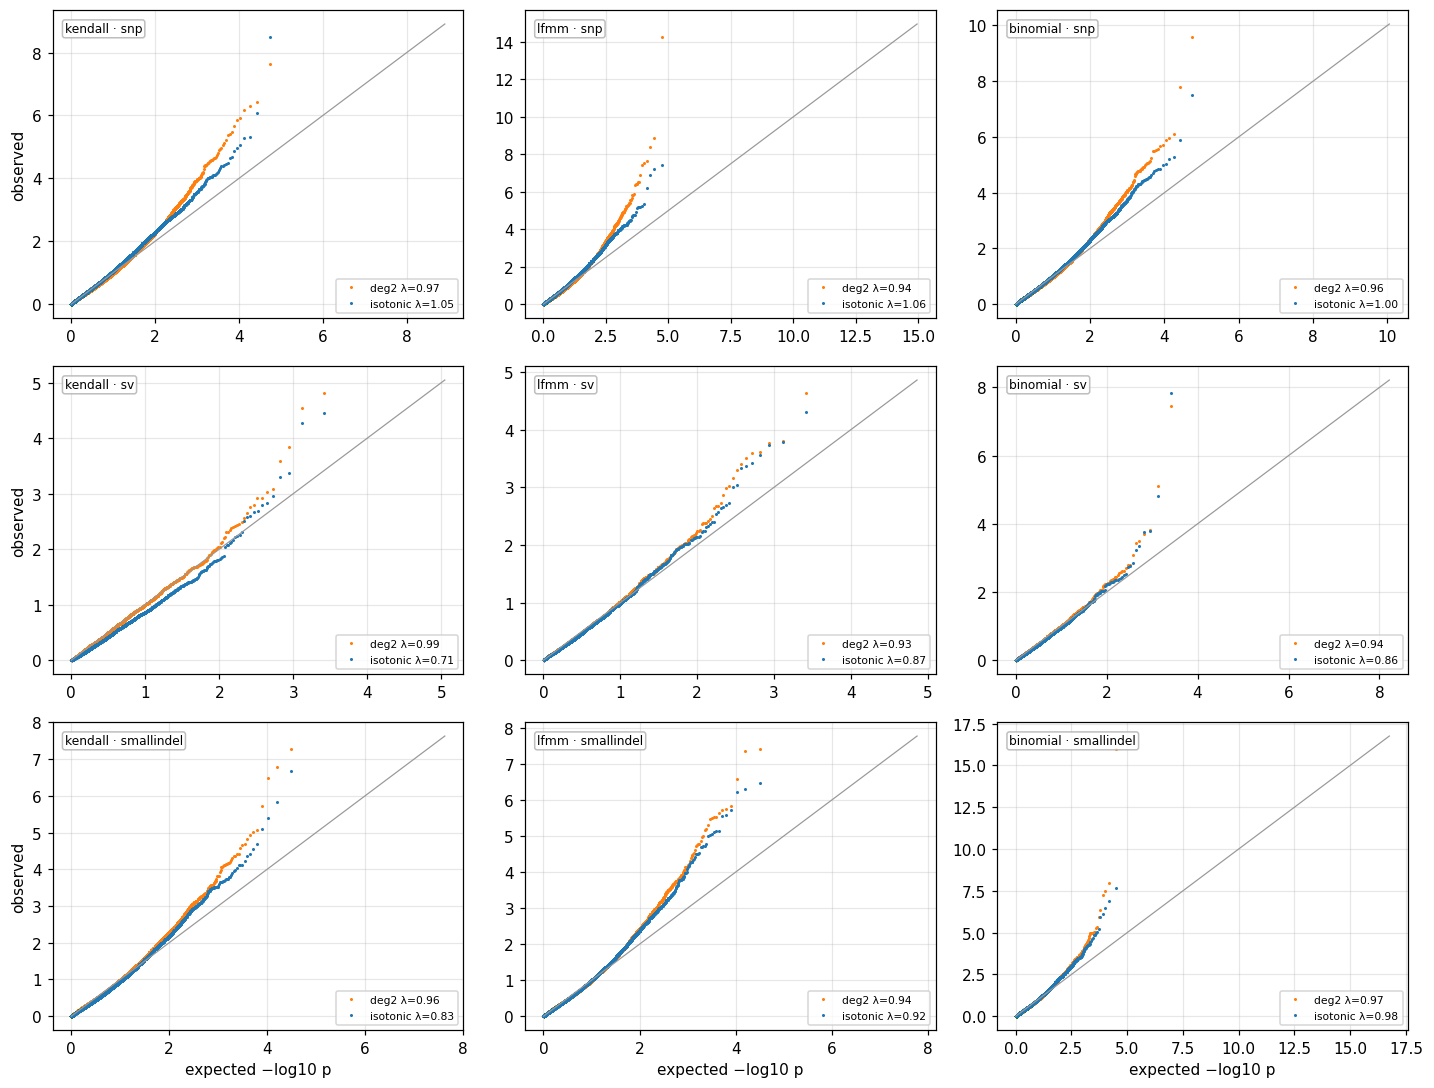

scheme               deg2  isotonic
class      model                   
smallindel binomial    18        10
           kendall      4         3
           lfmm        27        21
snp        binomial    35         2
           kendall     30         2
           lfmm        77        10
sv         binomial     2         2
           kendall      2         0
           lfmm         0         0


In [6]:
def lam(p):
    p=np.asarray(p,float); p=p[np.isfinite(p)&(p>0)]
    from scipy.stats import chi2
    return np.median(chi2.isf(p,1))/chi2.ppf(0.5,1)
def bh(p):
    p=np.asarray(p,float); ok=np.isfinite(p); q=np.full(len(p),np.nan)
    pp=p[ok]; o=np.argsort(pp); n=len(pp); r=np.empty(n)
    r[o]=np.minimum.accumulate((pp[o]*n/(np.arange(n)+1))[::-1])[::-1]; q[ok]=np.clip(r,0,1); return q

fig,axq=plt.subplots(3,3,figsize=(13,10))
hit=[]
for i,c in enumerate(CLASSES):
    for j,m in enumerate(MODELS):
        a=axq[i,j]; res=BLK[(m,c)]; x,me,sde=roll_curve(res)
        for how,col in [("deg2","tab:orange"),("isotonic","tab:blue")]:
            mp,sd=predict(res,x,me,sde,how); p=zpval(res,mp,sd)
            pp=np.sort(p[np.isfinite(p)&(p>0)]);
            if len(pp)==0: continue
            exp=-np.log10((np.arange(1,len(pp)+1))/(len(pp)+1)); obs=-np.log10(pp)
            a.plot(exp,obs,".",ms=2,color=col,label=f"{how} λ={lam(p):.2f}")
            q=bh(p); nb=int((q<0.05).sum())
            hit.append((m,c,how,nb,int((p==0).sum())))
        mx=max(a.get_xlim()[1],a.get_ylim()[1]); a.plot([0,mx],[0,mx],color="0.6",lw=.8)
        a.set_xlabel("expected −log10 p" if i==2 else ""); a.set_ylabel("observed" if j==0 else "")
        a.annotate(f"{m} · {c}",xy=(0.03,0.96),xycoords="axes fraction",va="top",fontsize=8,
                   bbox=dict(boxstyle="round,pad=0.2",fc="white",ec="0.7",alpha=.85))
        a.legend(fontsize=7,loc="lower right")
fig.tight_layout(); plt.show()
H=pd.DataFrame(hit,columns=["model","class","scheme","BH_sig","p==0"])
print(H.pivot_table(index=["class","model"],columns="scheme",values="BH_sig").to_string())

### Fate of specific deg-2 'hits' under the isotonic fix

In [7]:
ex=[]
for c in CLASSES:
    for m in MODELS:
        res=BLK[(m,c)].set_index("block"); x,me,sde=roll_curve(BLK[(m,c)])
        p2=zpval(BLK[(m,c)], *predict(BLK[(m,c)],x,me,sde,"deg2"))
        pi=zpval(BLK[(m,c)], *predict(BLK[(m,c)],x,me,sde,"isotonic"))
        d=BLK[(m,c)].assign(p_deg2=p2,p_iso=pi)
        z0=d[d["p_deg2"]==0]
        for _,r in z0.iterrows():
            ex.append((m,c,r["block"],int(r["SNPs"]),round(r["Z"],2),r["p_deg2"],float(f"{r['p_iso']:.2e}")))
ex=pd.DataFrame(ex,columns=["model","class","block","SNPs","Z","p_deg2","p_isotonic"])
print("Every deg-2 p==0 block and its honest isotonic p:")
print(ex.to_string(index=False) if len(ex) else "  (none)")

Every deg-2 p==0 block and its honest isotonic p:
   model class     block  SNPs     Z  p_deg2  p_isotonic
 kendall   snp Chr2_2819  1000 21.21     0.0    0.019900
 kendall   snp Chr3_6144  1000 20.43     0.0    0.023500
 kendall   snp Chr4_5404  1000 22.51     0.0    0.014900
binomial   snp Chr3_6144  1000 43.26     0.0    0.000291


## 6. Permutation null — is the fabrication signal-free, and is the null SD monotone?

Site-permute climate (bio1) across the 31 GrENE-Net sites → no real genotype-climate
association, LD + pool/site structure preserved → recompute a rank-correlation
(Spearman, same family as the Kendall model) → production block-Z → SD-vs-n. 20 reps.
Two questions:
1. **Does deg-2 fabricate p==0 even with NO real signal?** If yes → pure correction
   artifact (bars, right).
2. **Is the null SD-vs-n genuinely monotone-up-then-plateau** (justifying isotonic)
   or does it have a real hump (which would make isotonic an imposition)? (curves, left)
   Reported robustly via the isotonic-fit R² of the mean null curve and the
   plateau/low-n SD ratio — not the noise-dominated adjacent-step fraction.

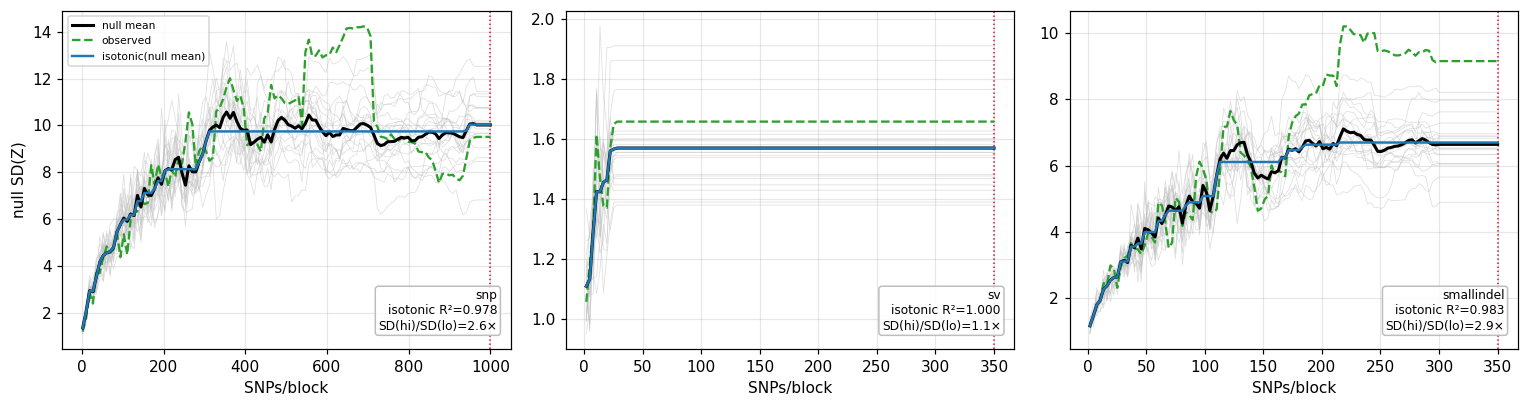

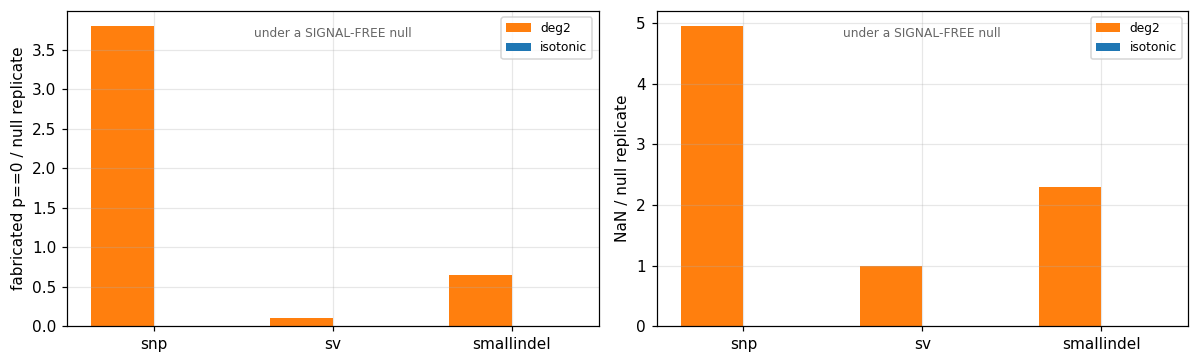

Per-class, mean over 20 null replicates:
  snp         deg2 p==0=3.80(max13) NaN=4.95 | isotonic p==0=0.00 NaN=0.00
  sv          deg2 p==0=0.10(max1) NaN=1.00 | isotonic p==0=0.00 NaN=0.00
  smallindel  deg2 p==0=0.65(max7) NaN=2.30 | isotonic p==0=0.00 NaN=0.00


In [8]:
d=np.load(f"{GEA}/wza_investigation/perm_null_sd.npz")
fig,axn=plt.subplots(1,3,figsize=(14,3.8))
for j,c in enumerate(CLASSES):
    g=d[f"{c}_grid"]; nullc=d[f"{c}_null"]; real=d[f"{c}_real"]
    a=axn[j]
    for r in range(nullc.shape[0]):
        a.plot(g,nullc[r],color="0.75",lw=.5,alpha=.5,zorder=1)
    mn=np.nanmean(nullc,0)
    a.plot(g,mn,color="k",lw=2,label="null mean",zorder=4)
    a.plot(g,real,color="tab:green",lw=1.5,ls="--",label="observed",zorder=3)
    ok=np.isfinite(mn)
    ir=IsotonicRegression(increasing=True,out_of_bounds="clip"); ir.fit(g[ok],mn[ok])
    fit=ir.predict(g[ok]); a.plot(g[ok],fit,color="tab:blue",lw=1.6,label="isotonic(null mean)",zorder=5)
    ss_res=np.nansum((mn[ok]-fit)**2); ss_tot=np.nansum((mn[ok]-np.nanmean(mn[ok]))**2)
    r2=1-ss_res/ss_tot if ss_tot>0 else np.nan
    ratio=np.nanmedian(mn[ok][-10:])/np.nanmedian(mn[ok][:10])
    a.axvline(CAP[c],color="crimson",ls=":",lw=1)
    a.set_xlabel("SNPs/block"); a.set_ylabel("null SD(Z)" if j==0 else "")
    a.annotate(f"{c}\nisotonic R²={r2:.3f}\nSD(hi)/SD(lo)={ratio:.1f}×",
        xy=(0.97,0.05),xycoords="axes fraction",ha="right",va="bottom",fontsize=8,
        bbox=dict(boxstyle="round,pad=0.25",fc="white",ec="0.7",alpha=.85))
    if j==0: a.legend(fontsize=7,loc="upper left")
fig.tight_layout(); plt.show()

# artifact bars: fabricated p==0 / NaN per null replicate, deg2 vs isotonic
fig,axb=plt.subplots(1,2,figsize=(11,3.4))
labels=CLASSES; xpos=np.arange(len(labels)); w=0.35
for k,(metric,ti) in enumerate([(0,"fabricated p==0 / null replicate"),(1,"NaN / null replicate")]):
    d2=[d[f"{c}_fab"][:,0 if k==0 else 1].mean() for c in CLASSES]
    di=[d[f"{c}_fab"][:,2 if k==0 else 3].mean() for c in CLASSES]
    axb[k].bar(xpos-w/2,d2,w,label="deg2",color="tab:orange")
    axb[k].bar(xpos+w/2,di,w,label="isotonic",color="tab:blue")
    axb[k].set_xticks(xpos,labels); axb[k].set_ylabel(ti); axb[k].legend(fontsize=8)
    axb[k].annotate("under a SIGNAL-FREE null",xy=(0.5,0.95),xycoords="axes fraction",
                    ha="center",va="top",fontsize=8,color="0.4")
fig.tight_layout(); plt.show()
print("Per-class, mean over 20 null replicates:")
for c in CLASSES:
    f=d[f"{c}_fab"]
    print(f"  {c:11s} deg2 p==0={f[:,0].mean():.2f}(max{int(f[:,0].max())}) NaN={f[:,1].mean():.2f} | "
          f"isotonic p==0={f[:,2].mean():.2f} NaN={f[:,3].mean():.2f}")

**Read:** if the isotonic-fit R² of the null-mean SD curve is high and SD(hi)/SD(lo)≫1,
the null SD genuinely rises then flattens → monotone isotonic is well-justified and
deg-2's *descending* arm is simply wrong. deg-2 fabricating p==0 under the signal-free
null (orange bars > 0) proves those "hits" are a pure correction artifact; isotonic
(blue) fabricates nothing.